In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay
)

In [3]:
sns.set_style("whitegrid")

# 1. Load the Data
df = pd.read_csv("preprocessed_data.csv")

# 2. Define Features (X) and Target (y)
major_cols = [
    'boolean_Computer Science',
    'boolean_Information Technology',
    'boolean_Electrical Engineering',
    'boolean_Mechanical Engineering',
    'boolean_Electronics and Communication'
]
feature_cols = ['age', 'gpa'] + major_cols
X = df[feature_cols]
y = df['placement_status']

# 3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Fit the Logistic Regression Model with Custom Weights
# Using the 3:1 ratio to prioritize catching "Not Placed" students
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight={0: 3.5, 1: 1})
log_reg.fit(X_train, y_train)

# 5. Make Predictions
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]
log_reg.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 3.5, 1: 1}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. De

In [5]:
print("Intercept:", log_reg.intercept_[0])
for f, c in zip(feature_cols, log_reg.coef_[0]):
    print(f"{f}: {c:.4f}")

Intercept: -8.252468486268453
age: 0.0066
gpa: 2.2583
boolean_Computer Science: -0.4254
boolean_Information Technology: -0.0490
boolean_Electrical Engineering: -0.1573
boolean_Mechanical Engineering: -0.1096
boolean_Electronics and Communication: 0.7362


Accuracy   : 0.7829
Error Rate : 0.2171
ROC AUC    : 0.7212

Classification Report:

                precision    recall  f1-score   support

Not Placed (0)       0.44      0.58      0.50        33
    Placed (1)       0.89      0.83      0.86       142

      accuracy                           0.78       175
     macro avg       0.67      0.70      0.68       175
  weighted avg       0.81      0.78      0.79       175



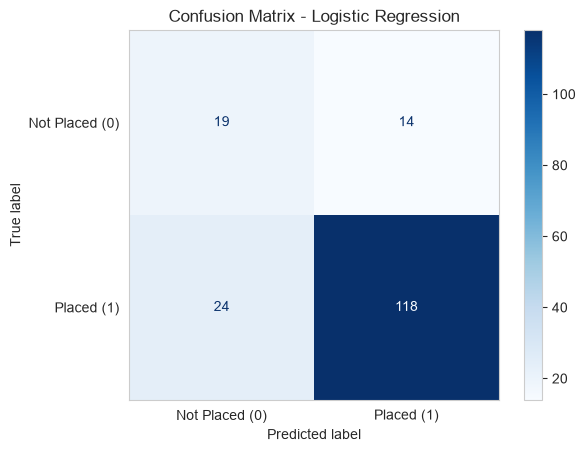

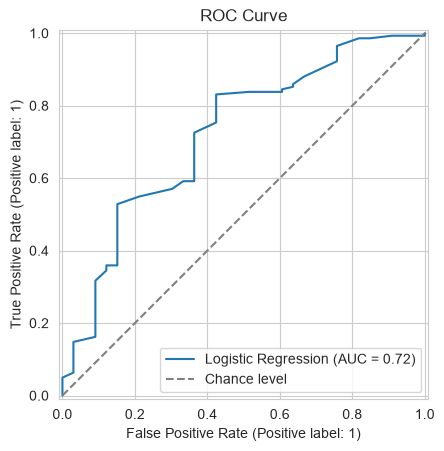

In [4]:
# 6. Print Core Metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Error Rate : {error_rate:.4f}")
print(f"ROC AUC    : {auc:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Placed (0)', 'Placed (1)']))

# 7. Plot the Single Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Placed (0)', 'Placed (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False) # Hides grid lines behind the matrix color blocks for a cleaner look
plt.show()

# 8. Plot the ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, name='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance level')
plt.title('ROC Curve')
plt.legend()
plt.show()